# Part 3 — Final Model: KMeans K=5

## 4. Final Model — KMeans K=5

In [6]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

BEST_K = 5
COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X)

sil = silhouette_score(X, df['Cluster'])
db  = davies_bouldin_score(X, df['Cluster'])
ch  = calinski_harabasz_score(X, df['Cluster'])

print(f"Final model — KMeans K={BEST_K}")
print(f"  Silhouette       : {sil:.4f}")
print(f"  Davies-Bouldin   : {db:.4f}  (lower is better)")
print(f"  Calinski-Harabasz: {ch:.1f}   (higher is better)")

# Recover original-scale centroids for plotting
scaler_orig = StandardScaler().fit(df[['Income', 'Spending']])
centroids_orig = scaler_orig.inverse_transform(km.cluster_centers_)

Final model — KMeans K=5
  Silhouette       : 0.5547
  Davies-Bouldin   : 0.5722  (lower is better)
  Calinski-Harabasz: 248.6   (higher is better)


## 5. Cluster Visualizations

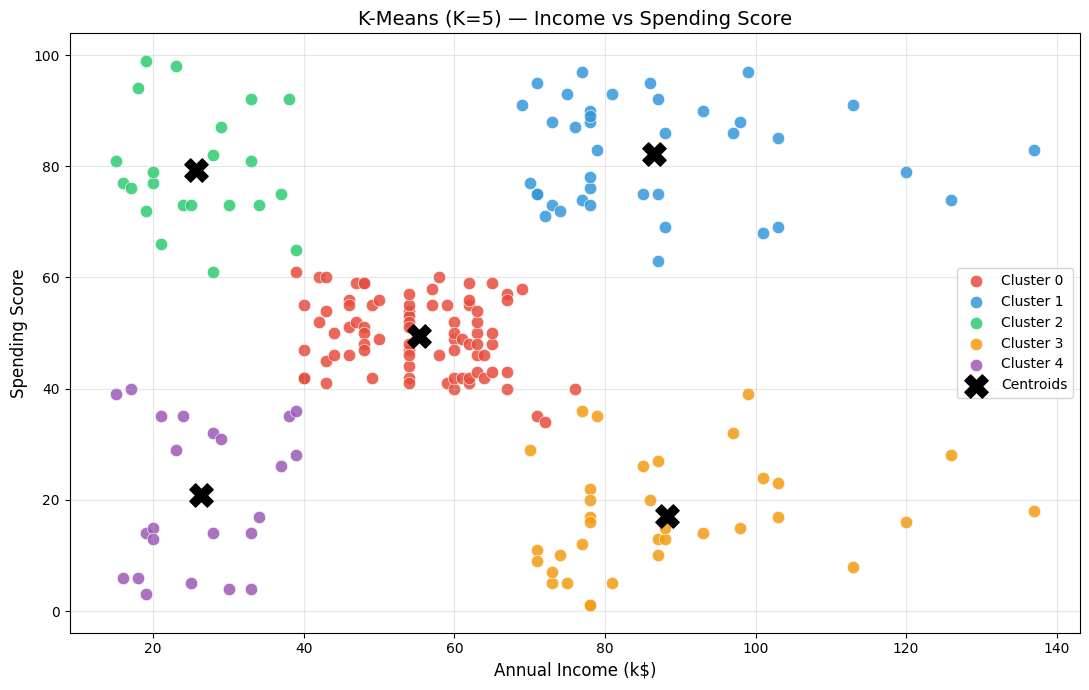

In [7]:
# Income vs Spending — main cluster plot
plt.figure(figsize=(11, 7))
for c in range(BEST_K):
    mask = df['Cluster'] == c
    plt.scatter(df[mask]['Income'], df[mask]['Spending'],
                c=COLORS[c], label=f'Cluster {c}', s=80, alpha=0.85, edgecolors='white', linewidth=0.5)
plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            c='black', marker='X', s=280, zorder=5, label='Centroids')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title(f'K-Means (K={BEST_K}) — Income vs Spending Score', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

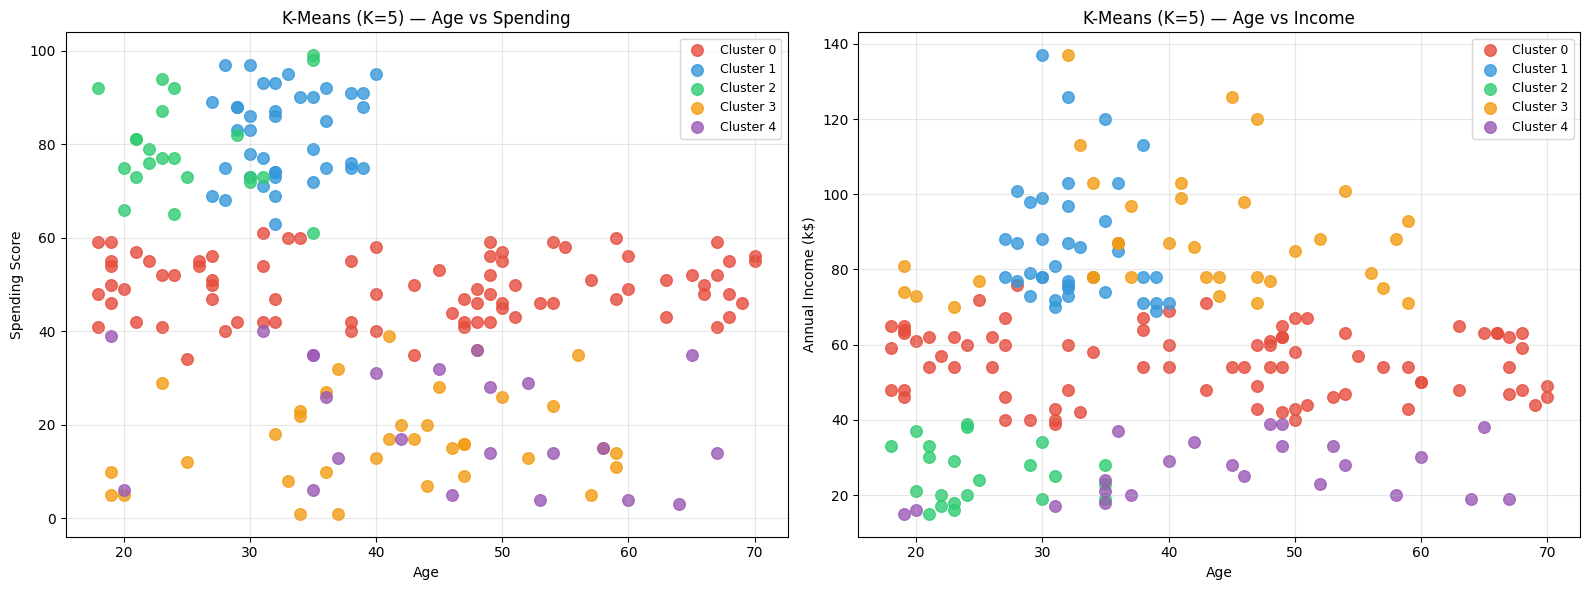

In [8]:
# Age vs Spending & Age vs Income side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(BEST_K):
    mask = df['Cluster'] == c
    axes[0].scatter(df[mask]['Age'], df[mask]['Spending'],
                    c=COLORS[c], label=f'Cluster {c}', s=70, alpha=0.8)
    axes[1].scatter(df[mask]['Age'], df[mask]['Income'],
                    c=COLORS[c], label=f'Cluster {c}', s=70, alpha=0.8)

axes[0].set_xlabel('Age'); axes[0].set_ylabel('Spending Score')
axes[0].set_title(f'K-Means (K={BEST_K}) — Age vs Spending')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Age'); axes[1].set_ylabel('Annual Income (k$)')
axes[1].set_title(f'K-Means (K={BEST_K}) — Age vs Income')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()